In [1]:
# Load the raw windowed data from before
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WINDOWED_DIR = Path(
    "/content/drive/MyDrive/processed_data/windowed"
)

saved_data = np.load(
    WINDOWED_DIR / "raw_windowed_gait_data.npz"
)

X_windows_raw = saved_data["X_windows"]
y_users = saved_data["y_users"]

window_metadata = pd.read_csv(
    WINDOWED_DIR / "raw_window_metadata.csv"
)

CHANNELS = [
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

print("Raw windowed data loaded")
print("-" * 40)
print(f"X_windows_raw shape: {X_windows_raw.shape}")
print(f"y_users shape:       {y_users.shape}")
print(f"Metadata shape:      {window_metadata.shape}")
print(f"Missing values:      {np.isnan(X_windows_raw).sum()}")
print(f"Number of users:     {len(np.unique(y_users))}")

Raw windowed data loaded
----------------------------------------
X_windows_raw shape: (1081, 500, 6)
y_users shape:       (1081,)
Metadata shape:      (1081, 6)
Missing values:      0
Number of users:     10


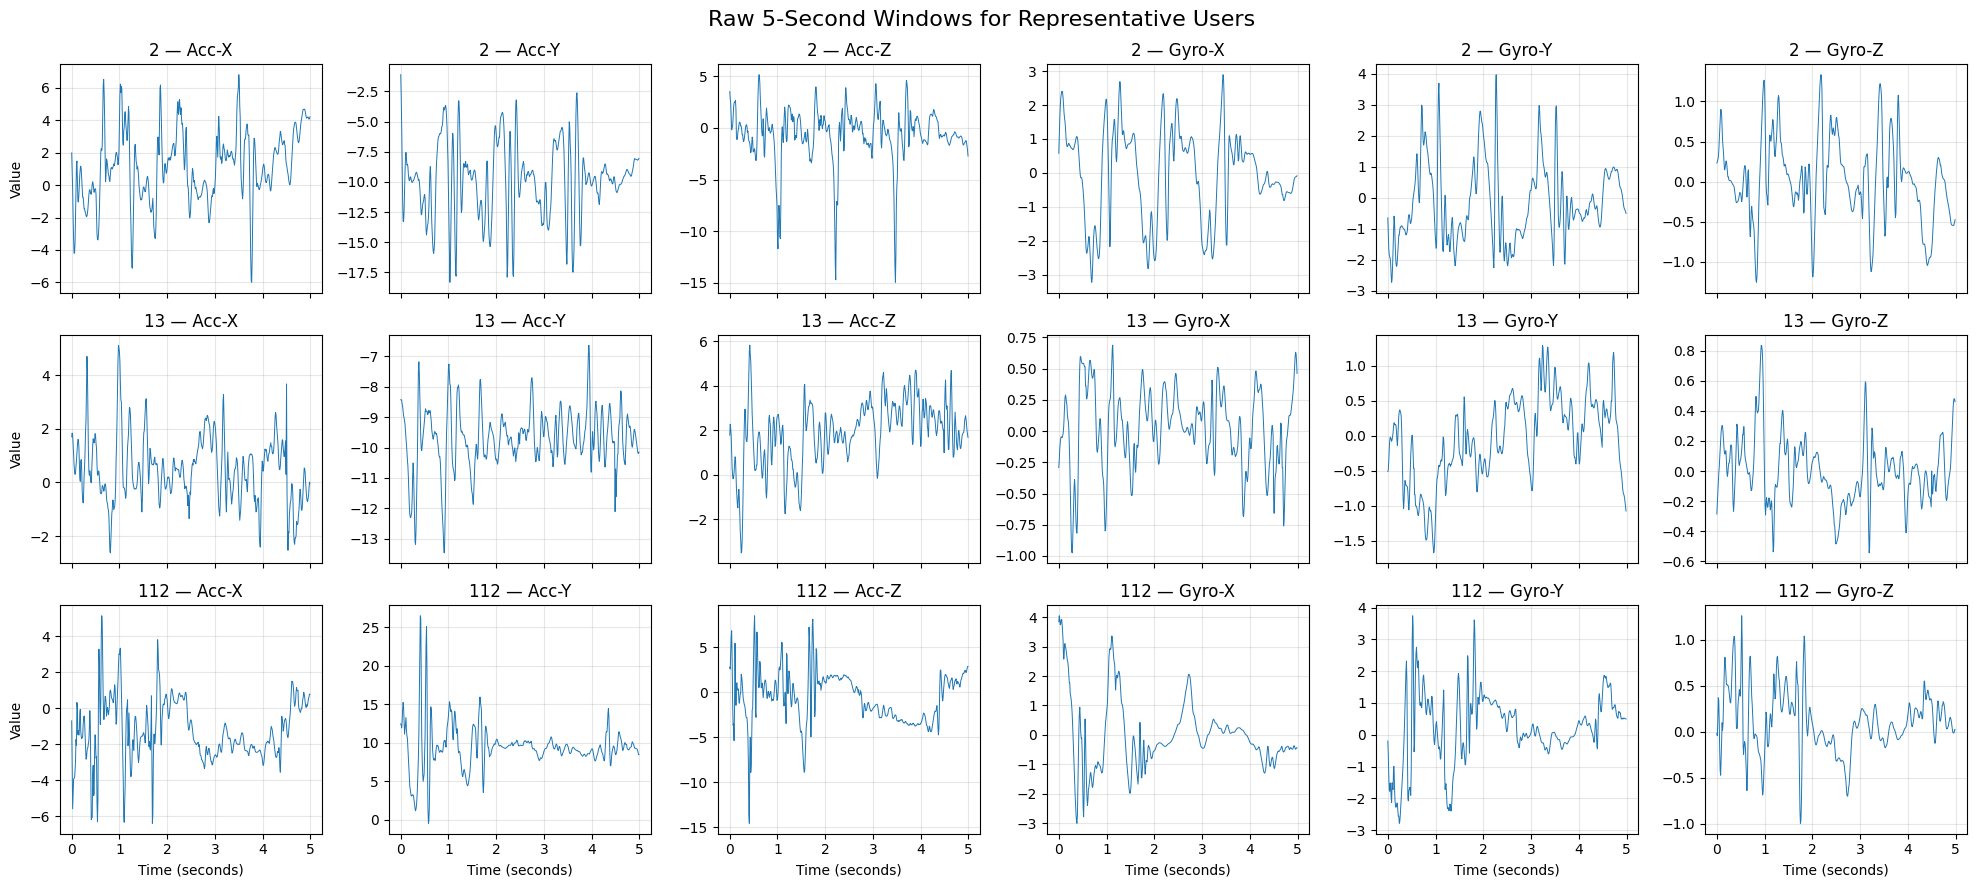

Potential IQR outliers across all windows:


,Channel,Potential outlier percentage
0,Acc-X,3.996
1,Acc-Y,4.579
2,Acc-Z,6.399
3,Gyro-X,2.184
4,Gyro-Y,2.434
5,Gyro-Z,2.597


In [2]:
# Analyze representative raw windows and estimate potential outliers

USER_IDS_TO_INSPECT = ["2", "13", "112"]

channels = [
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

# Plot the first window from three different users
fig, axes = plt.subplots(
    nrows=len(USER_IDS_TO_INSPECT),
    ncols=len(channels),
    figsize=(20, 9),
    sharex=True
)

for row, user_id in enumerate(USER_IDS_TO_INSPECT):

    # Find the first window belonging to this user
    window_index = np.where(y_users == user_id)[0][0]
    window = X_windows_raw[window_index]

    time_axis = np.arange(window.shape[0]) / 100

    for col, channel in enumerate(channels):
        axes[row, col].plot(
            time_axis,
            window[:, col],
            linewidth=0.7
        )

        axes[row, col].set_title(f"{user_id} — {channel}")
        axes[row, col].grid(True, alpha=0.3)

        if row == len(USER_IDS_TO_INSPECT) - 1:
            axes[row, col].set_xlabel("Time (seconds)")

        if col == 0:
            axes[row, col].set_ylabel("Value")

fig.suptitle(
    "Raw 5-Second Windows for Representative Users",
    fontsize=16
)

plt.tight_layout()
plt.show()


# IQR-based diagnostic for potential extreme values
# This identifies unusual values but does not remove them yet.

q1 = np.percentile(X_windows_raw, 25, axis=1)
q3 = np.percentile(X_windows_raw, 75, axis=1)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (X_windows_raw < lower_bound[:, np.newaxis, :]) |
    (X_windows_raw > upper_bound[:, np.newaxis, :])
)

outlier_percentages = (
    outlier_mask.mean(axis=(0, 1)) * 100
)

outlier_summary = pd.DataFrame({
    "Channel": channels,
    "Potential outlier percentage": np.round(
        outlier_percentages, 3
    )
})

print("Potential IQR outliers across all windows:")
display(outlier_summary)

In [4]:
# Apply cleaning to all windows and save the result
from scipy.signal import savgol_filter

SMOOTHING_WINDOW = 11
POLYNOMIAL_ORDER = 2

# Apply Savitzky-Golay smoothing along the time axis
X_windows_cleaned = savgol_filter(
    X_windows_raw,
    window_length=SMOOTHING_WINDOW,
    polyorder=POLYNOMIAL_ORDER,
    axis=1
).astype(np.float32)

print("Cleaning complete")
print(f"Raw data shape:     {X_windows_raw.shape}")
print(f"Cleaned data shape:  {X_windows_cleaned.shape}")
print(f"Cleaned data type:   {X_windows_cleaned.dtype}")
print(f"Missing values:      {np.isnan(X_windows_cleaned).sum()}")

Cleaning complete
Raw data shape:     (1081, 500, 6)
Cleaned data shape:  (1081, 500, 6)
Cleaned data type:   float32
Missing values:      0


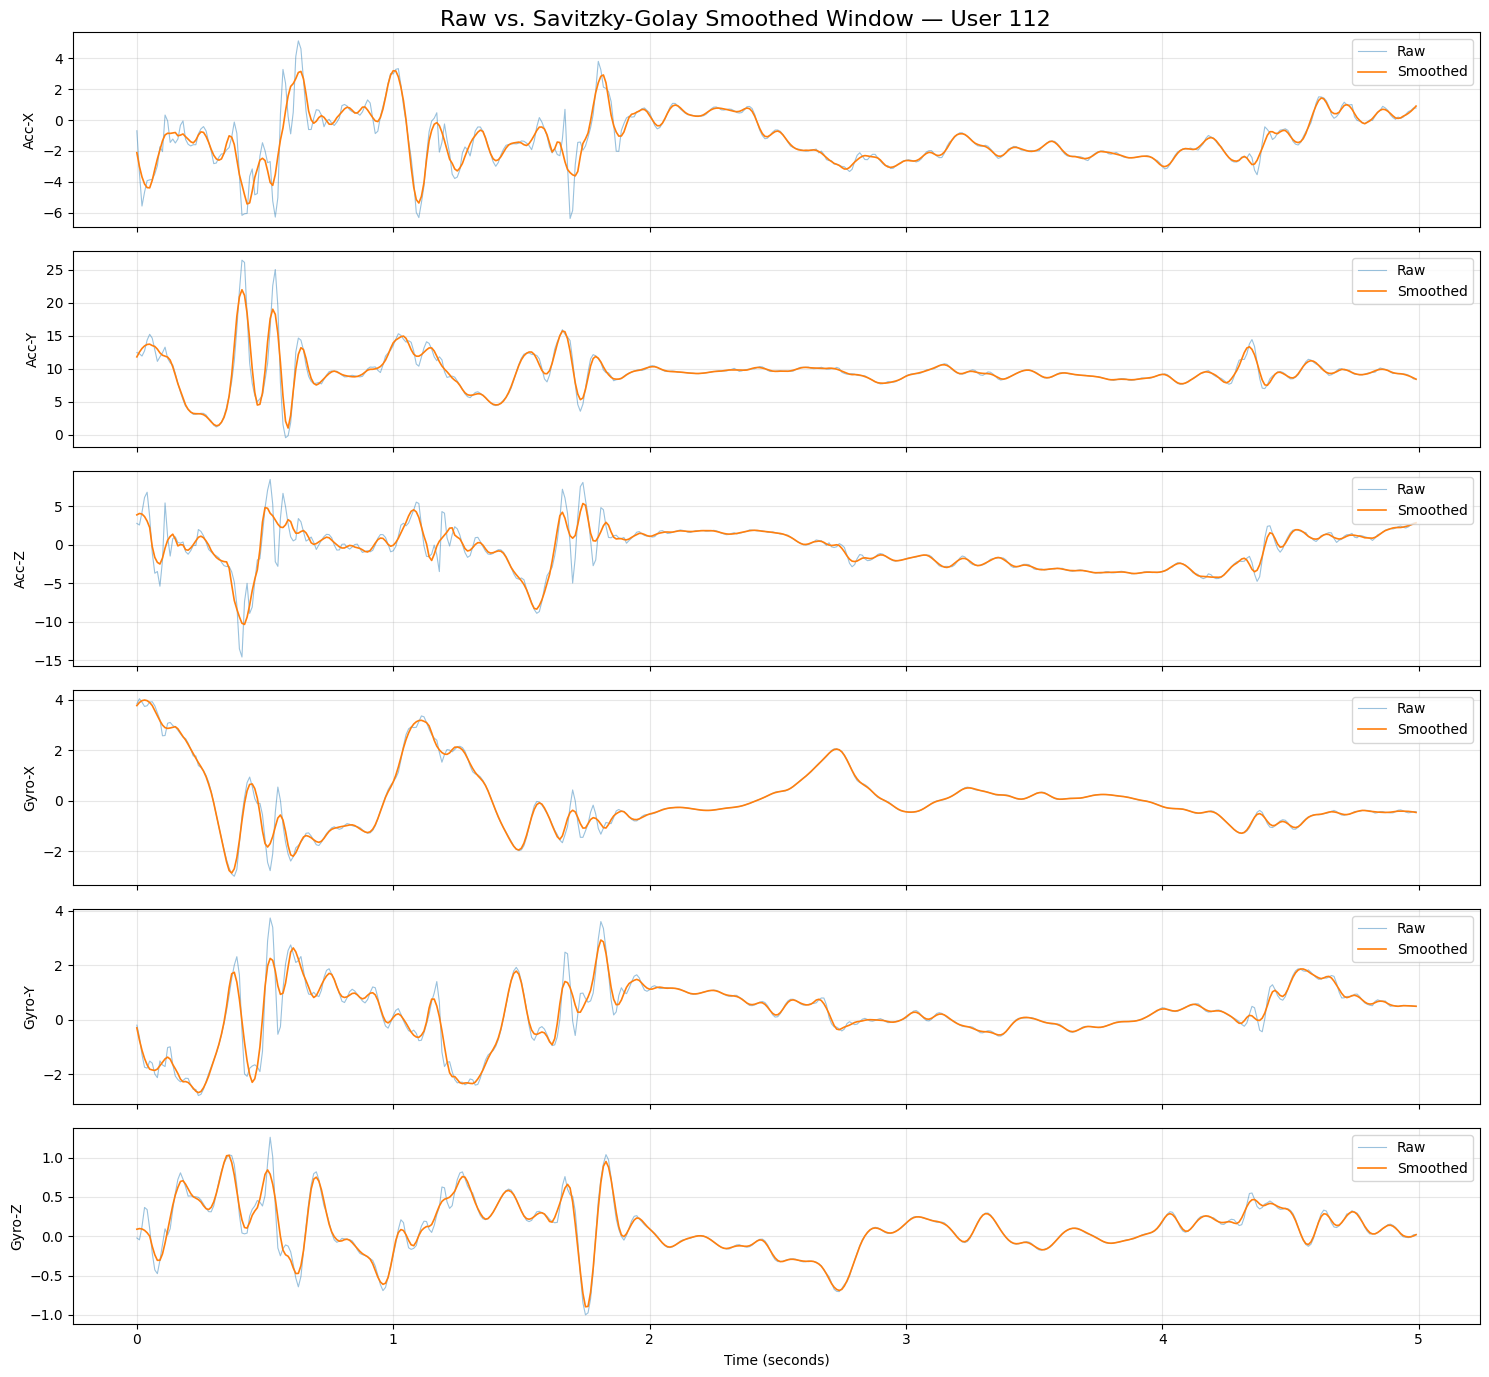

In [8]:
# Compare raw vs cleaned data
# Select one representative window from user 112
user_id_to_plot = "112"
SAMPLING_RATE = 100
WINDOW_SIZE = 500
STRIDE = 250
window_index = np.where(y_users == user_id_to_plot)[0][0]

raw_window = X_windows_raw[window_index]
cleaned_window = X_windows_cleaned[window_index]

time_axis = np.arange(raw_window.shape[0]) / SAMPLING_RATE

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

for channel_index, channel in enumerate(CHANNELS):
    axes[channel_index].plot(
        time_axis,
        raw_window[:, channel_index],
        alpha=0.45,
        linewidth=0.8,
        label="Raw"
    )

    axes[channel_index].plot(
        time_axis,
        cleaned_window[:, channel_index],
        linewidth=1.2,
        label="Smoothed"
    )

    axes[channel_index].set_ylabel(channel)
    axes[channel_index].grid(True, alpha=0.3)
    axes[channel_index].legend(loc="upper right")

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Raw vs. Savitzky-Golay Smoothed Window — User 112",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [9]:
CLEANED_PATH = WINDOWED_DIR / "cleaned_windowed_gait_data.npz"

np.savez_compressed(
    CLEANED_PATH,
    X_windows=X_windows_cleaned,
    y_users=y_users
)

print(f"Saved cleaned windowed data to:")
print(CLEANED_PATH)

Saved cleaned windowed data to:
/content/drive/MyDrive/processed_data/windowed/cleaned_windowed_gait_data.npz
